# <center> Homework 130

In [ ]:
from importlib import reload
import tf_data
import tf_model
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import SARIMA_model

2026-02-18 01:08:19.083631: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-18 01:08:20.215316: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-18 01:08:30.477214: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
2026-02-18 01:08:39.869876: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit

In [2]:
path = Path("datasets/CTA_-_Ridership_-_Daily_Boarding_Totals_20260211.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] 
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1) 
df = df.drop_duplicates() 

df['bus'] = df['bus'].str.replace(",", "").astype(float)
df['rail'] = df['rail'].str.replace(",", "").astype(float)

In [3]:
def MAPE(y_true, y_pred):
    return tf.reduce_mean(tf.abs((y_true - y_pred) / y_true))

In [4]:
df_mulvar = df[["bus", "rail"]] / 1e6
df_mulvar["next_day_type"] = df["day_type"].shift(-1)
df_mulvar = pd.get_dummies(df_mulvar).astype(np.float32)

df_mulvar.head()

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2001-01-01,0.297192,0.126455,0.0,0.0,1.0
2001-01-02,0.780827,0.501952,0.0,0.0,1.0
2001-01-03,0.824923,0.536432,0.0,0.0,1.0
2001-01-04,0.870021,0.550011,0.0,0.0,1.0
2001-01-05,0.890426,0.557917,1.0,0.0,0.0


In [5]:
mulvar_train = df_mulvar["2016-01":"2018-12"]
mulvar_valid = df_mulvar["2019-01":"2019-05"]
mulvar_test = df_mulvar["2019-06":]

## Task 0 

да се довръши имплементацията на SARIMA

In [19]:
rail_train = df['rail'][:'2018-12'].asfreq('D')
rail_test = df['rail']['2019-01-01':'2019-01-30']

In [24]:
from statsmodels.tsa.arima.model import ARIMA
reload(SARIMA_model)
from SARIMA_model import SARIMA

def test_custom_SARIMA(**params):
    custom = SARIMA(rail_train, **params).fit()
    custom_pred = custom.forecast(steps=30)

    y_true = df['rail'][custom_pred.index].asfreq('D')
    custom_mape = np.abs((y_true - custom_pred) / y_true).mean()

    original = ARIMA(rail_train, **params).fit()
    original_pred = original.forecast(steps=30)

    y_true = df['rail'][original_pred.index].asfreq('D')
    original_mape = ((y_true - original_pred) / y_true).abs().mean()

    return custom_mape, original_mape

In [21]:
test_custom_SARIMA(order=(2, 1, 2), seasonal_order=(2, 1, 2, 7))

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/zdravko/Machine_Learning_Intern/Machine_Learning/tensorflow/SARIMA_model.py:132: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  z_base = arma_pred[i]
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966:

(np.float64(0.842796925783744), np.float64(0.36942908021006604))

In [23]:
test_custom_SARIMA(order=(0, 0, 0), seasonal_order=(2, 1, 2, 7))

/home/zdravko/Machine_Learning_Intern/Machine_Learning/tensorflow/SARIMA_model.py:132: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  z_base = arma_pred[i]


(np.float64(0.3955949559392124), np.float64(0.38259101876727))

In [25]:
test_custom_SARIMA(order=(1, 1, 1), seasonal_order=(0, 1, 0, 7))

/home/zdravko/Machine_Learning_Intern/Machine_Learning/tensorflow/SARIMA_model.py:132: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  z_base = arma_pred[i]


(np.float64(0.41186571175819414), np.float64(0.4117580650572762))

## Task 1

да се тестват примерите от книгта.

### да се проследи на всяка стъпка какви данни се подават и какви се предават нататък

In [6]:
def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

In [7]:
my_series = tf.data.Dataset.range(7)
for item in my_series: 
    print(item)
print()

wind = to_windows(my_series, 3)
for item in wind: 
    print(item)
print()

dataset = to_windows(to_windows(my_series, 3), 4)
list(dataset)

tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(3, shape=(), dtype=int64)
tf.Tensor(4, shape=(), dtype=int64)
tf.Tensor(5, shape=(), dtype=int64)
tf.Tensor(6, shape=(), dtype=int64)



2026-02-17 16:56:11.352575: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


tf.Tensor([0 1 2], shape=(3,), dtype=int64)
tf.Tensor([1 2 3], shape=(3,), dtype=int64)
tf.Tensor([2 3 4], shape=(3,), dtype=int64)
tf.Tensor([3 4 5], shape=(3,), dtype=int64)
tf.Tensor([4 5 6], shape=(3,), dtype=int64)



2026-02-17 16:56:11.619489: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[<tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]])>,
 <tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[1, 2, 3],
        [2, 3, 4],
        [3, 4, 5],
        [4, 5, 6]])>]

In [8]:
dataset = dataset.map(lambda S: (S[:, 0], S[:, 1:]))
list(dataset)

2026-02-17 16:56:12.034487: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[(<tf.Tensor: shape=(4,), dtype=int64, numpy=array([0, 1, 2, 3])>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[1, 2],
         [2, 3],
         [3, 4],
         [4, 5]])>),
 (<tf.Tensor: shape=(4,), dtype=int64, numpy=array([1, 2, 3, 4])>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[2, 3],
         [3, 4],
         [4, 5],
         [5, 6]])>)]

In [33]:
seq_length = 56

def to_seq2seq_dataset(series, seq_length=56, ahead=14, target_col=1,
                                batch_size=32, shuffle=False, seed=None):
                                
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0], S[:, 1:, 1]))
    
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    
    return ds.batch(batch_size)

def to_seq2seq_dataset_steps_explain(series, seq_length=56, ahead=14, target_col=1,
                                batch_size=32, shuffle=False, seed=None):

    print('==== Step 1: Series to Tensors ====')
    for item in tf.data.Dataset.from_tensor_slices(series).take(3):
        print(item)
    
    print('\n')
    print('==== Step 2: Tensors to Sequences with len ahead + 1 ====')
    for item in to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1).take(1):
        print(item)

    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    print('\n')
    print('==== Step 3: Group Sequences to Sequences with len seq_length ====')
    for item in to_windows(ds, seq_length).take(1):
        print(item)

    ds = to_windows(ds, seq_length)
    
    print('\n')
    print('==== Step 4: Divide on Training Seq and Target Seq ====')
    for item in ds.map(lambda S: (S[:, 0], S[:, 1:, 1])).take(1):
        print(item)

    ds = ds.map(lambda S: (S[:, 0], S[:, 1:, 1]))

    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    
    print('\n')
    print('==== Step 5: Make Batches ====')
    for item in ds.batch(batch_size).take(1):
        print(item)

    return ds.batch(batch_size)

In [10]:
to_seq2seq_dataset_steps_explain(mulvar_train, shuffle=True, seed=42)

==== Step 1: Series to Tensors ====
tf.Tensor([0.303321 0.319835 1.       0.       0.      ], shape=(5,), dtype=float32)
tf.Tensor([0.448859 0.365509 0.       1.       0.      ], shape=(5,), dtype=float32)
tf.Tensor([0.34054  0.287661 0.       0.       1.      ], shape=(5,), dtype=float32)


==== Step 2: Tensors to Sequences with len ahead + 1 ====
tf.Tensor(
[[0.303321 0.319835 1.       0.       0.      ]
 [0.448859 0.365509 0.       1.       0.      ]
 [0.34054  0.287661 0.       0.       1.      ]
 [0.829429 0.703185 0.       0.       1.      ]
 [0.846789 0.727716 0.       0.       1.      ]
 [0.853904 0.733167 0.       0.       1.      ]
 [0.846274 0.736809 0.       0.       1.      ]
 [0.841494 0.732495 1.       0.       0.      ]
 [0.469539 0.391597 0.       1.       0.      ]
 [0.306896 0.263073 0.       0.       1.      ]
 [0.753006 0.694734 0.       0.       1.      ]
 [0.760149 0.705694 0.       0.       1.      ]
 [0.78722  0.716663 0.       0.       1.      ]
 [0.859099 0.7

2026-02-17 16:57:31.331496: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 5), dtype=tf.float32, name=None), TensorSpec(shape=(None, None, None), dtype=tf.float32, name=None))>

In [34]:
seq2seq_train_org = to_seq2seq_dataset(mulvar_train, shuffle=True, seed=42)
seq2seq_valid_org = to_seq2seq_dataset(mulvar_valid)

In [ ]:
seq2seq_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

seq2seq_model.compile(loss=tf.keras.losses.Huber(), optimizer=tf.keras.optimizers.Adam(0.01), metrics=['mae'])
callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
seq2seq_model.fit(seq2seq_train_org, epochs=100, validation_data=(seq2seq_valid_org), callbacks=callbacks)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0333 - mae: 0.1765 - val_loss: 0.0084 - val_mae: 0.0936
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0062 - mae: 0.0772 - val_loss: 0.0053 - val_mae: 0.0675
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0046 - mae: 0.0636 - val_loss: 0.0045 - val_mae: 0.0595
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0041 - mae: 0.0580 - val_loss: 0.0042 - val_mae: 0.0558
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0038 - mae: 0.0554 - val_loss: 0.0057 - val_mae: 0.0768
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0037 - mae: 0.0545 - val_loss: 0.0040 - val_mae: 0.0539
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0036 - mae: 0.0528 - val_loss: 0.0042 - val_mae: 0.0576
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0035 - mae: 0.0516 - val_loss: 0.0047 - val_mae: 0.0641
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - lo

2026-02-17 17:02:06.876403: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0031 - mae: 0.0481 - val_loss: 0.0038 - val_mae: 0.0510
Epoch 25/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0031 - mae: 0.0483 - val_loss: 0.0039 - val_mae: 0.0545
Epoch 26/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0033 - mae: 0.0509 - val_loss: 0.0038 - val_mae: 0.0510
Epoch 27/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0031 - mae: 0.0477 - val_loss: 0.0043 - val_mae: 0.0606
Epoch 28/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0031 - mae: 0.0477 - val_loss: 0.0037 - val_mae: 0.0497
Epoch 29/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0031 - mae: 0.0485 - val_loss: 0.0037 - val_mae: 0.0483
Epoch 30/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0032 - mae: 0.0497 - val_loss: 0.0038 - val_mae: 0.0516


In [17]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]
y_pred_14 = seq2seq_model.predict(X)[0, -1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


In [23]:
mulvar_valid.head()

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2019-01-01,0.248879,0.245852,0.0,0.0,1.0
2019-01-02,0.591006,0.573542,0.0,0.0,1.0
2019-01-03,0.664442,0.627781,0.0,0.0,1.0
2019-01-04,0.668812,0.628514,1.0,0.0,0.0
2019-01-05,0.444434,0.348257,0.0,1.0,0.0


In [19]:
X

array([[[0.248879, 0.245852, 0.      , 0.      , 1.      ],
        [0.591006, 0.573542, 0.      , 0.      , 1.      ],
        [0.664442, 0.627781, 0.      , 0.      , 1.      ],
        [0.668812, 0.628514, 1.      , 0.      , 0.      ],
        [0.444434, 0.348257, 0.      , 1.      , 0.      ],
        [0.318623, 0.260556, 0.      , 0.      , 1.      ],
        [0.723023, 0.66247 , 0.      , 0.      , 1.      ],
        [0.784085, 0.701693, 0.      , 0.      , 1.      ],
        [0.747949, 0.685444, 0.      , 0.      , 1.      ],
        [0.74785 , 0.690162, 0.      , 0.      , 1.      ],
        [0.763718, 0.679115, 1.      , 0.      , 0.      ],
        [0.382464, 0.325219, 0.      , 1.      , 0.      ],
        [0.301855, 0.250222, 0.      , 0.      , 1.      ],
        [0.75659 , 0.705571, 0.      , 0.      , 1.      ],
        [0.783113, 0.720095, 0.      , 0.      , 1.      ],
        [0.800537, 0.728048, 0.      , 0.      , 1.      ],
        [0.800348, 0.734929, 0.      , 0

In [21]:
pred = seq2seq_model.predict(X)
print(pred.shape)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
(1, 56, 14)


array([[[0.5734018 , 0.4366796 , 0.4442495 , 0.542246  , 0.45162147,
         0.46461082, 0.37470245, 0.601574  , 0.61593515, 0.47203663,
         0.46013835, 0.57663494, 0.46390378, 0.4601798 ],
        [0.6464703 , 0.55413204, 0.5533524 , 0.49579355, 0.4547276 ,
         0.31395012, 0.57542   , 0.65411514, 0.57656723, 0.5505105 ,
         0.4810145 , 0.48266962, 0.47416127, 0.6352736 ],
        [0.6667775 , 0.60373074, 0.50634587, 0.3599727 , 0.3230418 ,
         0.5022498 , 0.6791778 , 0.63906777, 0.6095842 , 0.51168853,
         0.37971163, 0.35125214, 0.59700227, 0.7226263 ],
        [0.32593104, 0.27315837, 0.4938289 , 0.44841182, 0.6282797 ,
         0.7287102 , 0.72591054, 0.40340853, 0.29207432, 0.43884197,
         0.41163972, 0.65882653, 0.8547211 , 0.7292295 ],
        [0.3207115 , 0.49214387, 0.5404841 , 0.68681675, 0.7882304 ,
         0.7255836 , 0.46822348, 0.27921557, 0.52447563, 0.4956851 ,
         0.6917834 , 0.7669238 , 0.72576   , 0.45932835],
        [0.6550075 ,

In [18]:
y_pred_14

array([0.72513217, 0.7333549 , 0.7271959 , 0.66801137, 0.37830293,
       0.25425896, 0.6631636 , 0.7164373 , 0.7161028 , 0.70501   ,
       0.67931294, 0.35003376, 0.29020363, 0.67652535], dtype=float32)

<Axes: xlabel='date'>

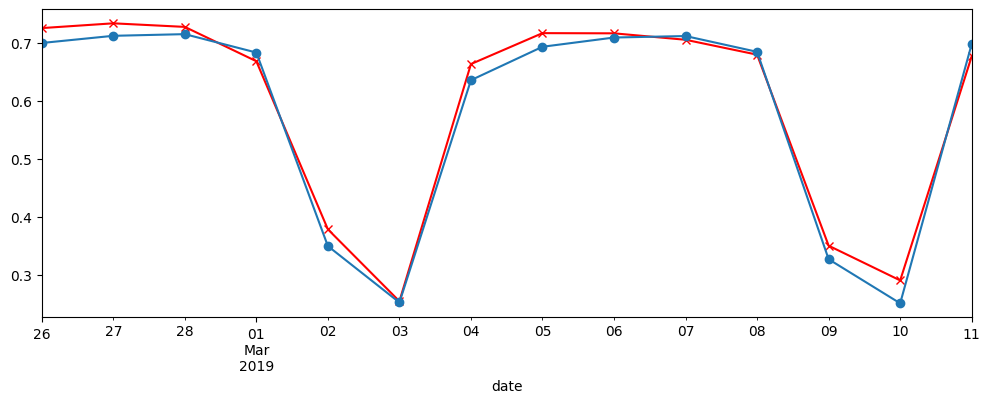

In [26]:
y_true = mulvar_valid['rail'][seq_length:seq_length + 14]
y_pred_14 = pd.Series(y_pred_14, y_true.index)

fig, ax = plt.subplots(figsize=(12, 4))

y_pred_14.plot(ax=ax, c='r', marker='x')
y_true.plot(ax=ax, marker='o')

### след като тръгне с оргиналните класове да се тества с нашата имплементация

In [27]:
reload(tf_data)
from tf_data import Dataset

my_series = Dataset.range(7)
for item in my_series: 
    print(item)
print()

wind = to_windows(my_series, 3)
for item in wind: 
    print(item)
print()

dataset = to_windows(to_windows(my_series, 3), 4)
list(dataset)

tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)

tf.Tensor([0 1 2], shape=(3,), dtype=int32)
tf.Tensor([1 2 3], shape=(3,), dtype=int32)
tf.Tensor([2 3 4], shape=(3,), dtype=int32)
tf.Tensor([3 4 5], shape=(3,), dtype=int32)
tf.Tensor([4 5 6], shape=(3,), dtype=int32)



[<tf.Tensor: shape=(4, 3), dtype=int32, numpy=
 array([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]], dtype=int32)>,
 <tf.Tensor: shape=(4, 3), dtype=int32, numpy=
 array([[1, 2, 3],
        [2, 3, 4],
        [3, 4, 5],
        [4, 5, 6]], dtype=int32)>]

In [28]:
dataset = dataset.map(lambda S: (S[:, 0], S[:, 1:]))
list(dataset)

[(<tf.Tensor: shape=(4,), dtype=int32, numpy=array([0, 1, 2, 3], dtype=int32)>,
  <tf.Tensor: shape=(4, 2), dtype=int32, numpy=
  array([[1, 2],
         [2, 3],
         [3, 4],
         [4, 5]], dtype=int32)>),
 (<tf.Tensor: shape=(4,), dtype=int32, numpy=array([1, 2, 3, 4], dtype=int32)>,
  <tf.Tensor: shape=(4, 2), dtype=int32, numpy=
  array([[2, 3],
         [3, 4],
         [4, 5],
         [5, 6]], dtype=int32)>)]

In [7]:
reload(tf_data)
from tf_data import Dataset

seq_length = 56

def to_seq2seq_dataset(series, seq_length=56, ahead=14, target_col=1,
                                batch_size=32, shuffle=False, seed=None, cache_fname=None):
                                
    ds = to_windows(Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0], S[:, 1:, target_col]))
    
    if cache_fname is not None:
        ds = ds.cache(cache_fname)

    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    
    return ds.batch(batch_size)

def to_seq2seq_dataset_steps_explain(series, seq_length=56, ahead=14, target_col=1,
                                batch_size=32, shuffle=False, seed=None):
    
    reload(tf_data)
    from tf_data import Dataset

    print('==== Step 1: Series to Tensors ====')
    for item in Dataset.from_tensor_slices(series).take(3):
        print(item)
    
    print('\n')
    print('==== Step 2: Tensors to Sequences with len ahead + 1 ====')
    for item in to_windows(Dataset.from_tensor_slices(series), ahead + 1).take(1):
        print(item)

    ds = to_windows(Dataset.from_tensor_slices(series), ahead + 1)
    print('\n')
    print('==== Step 3: Group Sequences to Sequences with len seq_length ====')
    for item in to_windows(ds, seq_length).take(1):
        print(item)

    ds = to_windows(ds, seq_length)
    
    print('\n')
    print('==== Step 4: Divide on Training Seq and Target Seq ====')
    for item in ds.map(lambda S: (S[:, 0], S[:, 1:, target_col])).take(1):
        print(item)

    ds = ds.map(lambda S: (S[:, 0], S[:, 1:, 1]))

    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    
    print('\n')
    print('==== Step 5: Make Batches ====')
    for item in ds.batch(batch_size).take(1):
        print(item)

    return ds.batch(batch_size)

In [33]:
to_seq2seq_dataset_steps_explain(mulvar_train, shuffle=True, seed=42)

==== Step 1: Series to Tensors ====
tf.Tensor([0.303321 0.319835 1.       0.       0.      ], shape=(5,), dtype=float32)
tf.Tensor([0.448859 0.365509 0.       1.       0.      ], shape=(5,), dtype=float32)
tf.Tensor([0.34054  0.287661 0.       0.       1.      ], shape=(5,), dtype=float32)


==== Step 2: Tensors to Sequences with len ahead + 1 ====
tf.Tensor(
[[0.303321 0.319835 1.       0.       0.      ]
 [0.448859 0.365509 0.       1.       0.      ]
 [0.34054  0.287661 0.       0.       1.      ]
 [0.829429 0.703185 0.       0.       1.      ]
 [0.846789 0.727716 0.       0.       1.      ]
 [0.853904 0.733167 0.       0.       1.      ]
 [0.846274 0.736809 0.       0.       1.      ]
 [0.841494 0.732495 1.       0.       0.      ]
 [0.469539 0.391597 0.       1.       0.      ]
 [0.306896 0.263073 0.       0.       1.      ]
 [0.753006 0.694734 0.       0.       1.      ]
 [0.760149 0.705694 0.       0.       1.      ]
 [0.78722  0.716663 0.       0.       1.      ]
 [0.859099 0.7

In [11]:
reload(tf_data)

seq2seq_train_cus = to_seq2seq_dataset(mulvar_train, shuffle=True, seed=42, cache_fname='cache/seq2seq_model_train_cache.pkl')
seq2seq_valid_cus = to_seq2seq_dataset(mulvar_valid, cache_fname='cache/seq2seq_model_valid_cache.pkl')

In [ ]:
for i, item in enumerate(seq2seq_train_cus):
    print(i, end=' ')

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 

In [18]:
reload(tf_model)
from tf_model import Sequential, SimpleRNN, Dense, Input, EarlyStopping, Adam

seq2seq_model = Sequential([
    Input([None, 5]),
    SimpleRNN(32, return_sequences=True),
    Dense(14)
])

seq2seq_model.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])
callbacks = [EarlyStopping(patience=20, restore_best_weights=True)]
seq2seq_model.fit(seq2seq_train_cus, epochs=100, validation_data=(seq2seq_valid_cus), callbacks=callbacks)

Epoch 1/100


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

33it [00:09,  3.61it/s]


    - loss: 0.167 - meanabsolutepercentageerror: 0.314
    - val_loss: 0.075 - val_meanabsolutepercentageerror: 0.188
    - Learning Rate: 0.01
Epoch 2/100


...

    - loss: 0.046 - meanabsolutepercentageerror: 0.101
    - val_loss: 0.055 - val_meanabsolutepercentageerror: 0.145
    - Learning Rate: 0.01
Epoch 44/100


33it [00:02, 15.79it/s]


    - loss: 0.047 - meanabsolutepercentageerror: 0.101
    - val_loss: 0.053 - val_meanabsolutepercentageerror: 0.141
    - Learning Rate: 0.01
Epoch 45/100


33it [00:01, 16.54it/s]


    - loss: 0.045 - meanabsolutepercentageerror: 0.098
    - val_loss: 0.045 - val_meanabsolutepercentageerror: 0.119
    - Learning Rate: 0.01


In [27]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]
y_pred_14 = seq2seq_model.predict(X)[0, -1]

In [28]:
y_pred_14

<tf.Tensor: shape=(14,), dtype=float32, numpy=
array([0.74548006, 0.7859448 , 0.79983497, 0.7475879 , 0.451235  ,
       0.3247294 , 0.7117662 , 0.75618505, 0.73189473, 0.7929918 ,
       0.7047341 , 0.39282548, 0.2728582 , 0.70361876], dtype=float32)>

<Axes: xlabel='date'>

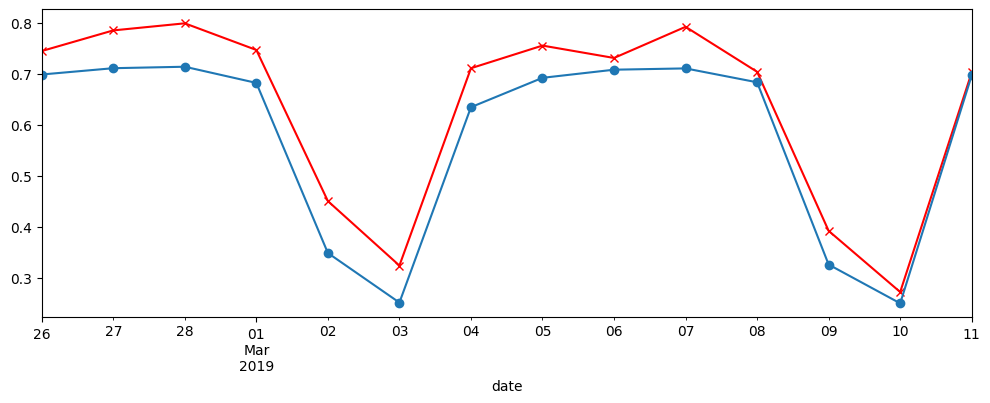

In [29]:
y_true = mulvar_valid['rail'][seq_length:seq_length + 14]
y_pred_14 = pd.Series(y_pred_14, y_true.index)

fig, ax = plt.subplots(figsize=(12, 4))

y_pred_14.plot(ax=ax, c='r', marker='x')
y_true.plot(ax=ax, marker='o')

## Task 2

да се имплмеентира класа Conv1D

## Task 3

в примера от книгата да се подмени Dense слоя с Conv1D

    да се сравнят резултаите.
    след като тръгне с оргиналните класове да се тества с нашата имплементация


In [35]:
seq2seq_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

seq2seq_model.compile(loss=tf.keras.losses.Huber(), optimizer=tf.keras.optimizers.Adam(0.01), metrics=['mae'])
callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
seq2seq_model.fit(seq2seq_train_org, epochs=100, validation_data=(seq2seq_valid_org), callbacks=callbacks)

Epoch 1/100


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     33/Unknown 5s 53ms/step - loss: 0.0765 - mae: 0.2804

2026-02-17 20:11:11.110983: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0340 - mae: 0.1771 - val_loss: 0.0074 - val_mae: 0.0846
Epoch 2/100


...

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0038 - mae: 0.0547 - val_loss: 0.0040 - val_mae: 0.0528
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0036 - mae: 0.0532 - val_loss: 0.0039 - val_mae: 0.0518
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0036 - mae: 0.0534 - val_loss: 0.0045 - val_mae: 0.0620
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0035 - mae: 0.0521 - val_loss: 0.0040 - val_mae: 0.0534
Epoch 9/100


2026-02-17 20:11:21.598371: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0034 - mae: 0.0508 - val_loss: 0.0040 - val_mae: 0.0529
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0035 - mae: 0.0527 - val_loss: 0.0038 - val_mae: 0.0519
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0035 - mae: 0.0518 - val_loss: 0.0041 - val_mae: 0.0554
Epoch 12/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0033 - mae: 0.0497 - val_loss: 0.0038 - val_mae: 0.0502
Epoch 13/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 317ms/step - loss: 0.0033 - mae: 0.0503 - val_loss: 0.0038 - val_mae: 0.0498
Epoch 14/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0033 - mae: 0.0504 - val_loss: 0.0039 - val_mae: 0.0517
Epoch 15/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0033 - mae: 0.0498 - val_loss: 0.0047 - val_mae: 0.0653
Epoch 16/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0032 - mae: 0.0489 - val_loss: 0.0046 - val_mae: 0.0618
Epoch 17/100
 1/33 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - los

2026-02-17 20:11:38.961363: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0035 - mae: 0.0535 - val_loss: 0.0039 - val_mae: 0.0530
Epoch 18/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0033 - mae: 0.0502 - val_loss: 0.0041 - val_mae: 0.0554
Epoch 19/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0033 - mae: 0.0500 - val_loss: 0.0038 - val_mae: 0.0497
Epoch 20/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0033 - mae: 0.0494 - val_loss: 0.0039 - val_mae: 0.0518
Epoch 21/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0032 - mae: 0.0486 - val_loss: 0.0037 - val_mae: 0.0500
Epoch 22/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0031 - mae: 0.0478 - val_loss: 0.0040 - val_mae: 0.0533
Epoch 23/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0031 - mae: 0.0481 - val_loss: 0.0042 - val_mae: 0.0576
Epoch 24/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0031 - mae: 0.0474 - val_loss: 0.0039 - val_mae: 0.0524
Epoch 25/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 

In [36]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]
y_pred_14_dense = seq2seq_model.predict(X)[0, -1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


In [37]:
seq2seq_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Conv1D(14, kernel_size=1)
])

seq2seq_model.compile(loss=tf.keras.losses.Huber(), optimizer=tf.keras.optimizers.Adam(0.01), metrics=['mae'])
callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
seq2seq_model.fit(seq2seq_train_org, epochs=100, validation_data=(seq2seq_valid_org), callbacks=callbacks)

Epoch 1/100


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     33/Unknown 3s 21ms/step - loss: 0.0918 - mae: 0.3068

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0392 - mae: 0.1909 - val_loss: 0.0087 - val_mae: 0.0955
Epoch 2/100
 1/33 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 0.0081 - mae: 0.0974

2026-02-17 20:14:32.983672: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0067 - mae: 0.0819 - val_loss: 0.0050 - val_mae: 0.0656
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0048 - mae: 0.0651 - val_loss: 0.0038 - val_mae: 0.0527
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0041 - mae: 0.0585 - val_loss: 0.0038 - val_mae: 0.0523
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0039 - mae: 0.0559 - val_loss: 0.0041 - val_mae: 0.0578
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0037 - mae: 0.0541 - val_loss: 0.0035 - val_mae: 0.0493
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0038 - mae: 0.0551 - val_loss: 0.0036 - val_mae: 0.0497
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0035 - mae: 0.0517 - val_loss: 0.0040 - val_mae: 0.0561
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0035 - mae: 0.0523 - val_loss: 0.0042 - val_mae: 0.0583
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0036 

In [38]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]
y_pred_14_conv = seq2seq_model.predict(X)[0, -1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step


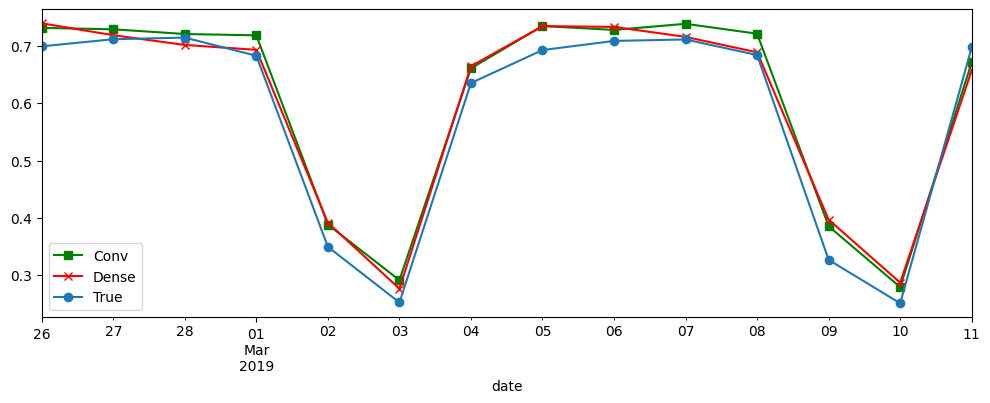

In [39]:
y_true = mulvar_valid['rail'][seq_length:seq_length + 14]
y_pred_14_dense = pd.Series(y_pred_14_dense, y_true.index)
y_pred_14_conv  = pd.Series(y_pred_14_conv, y_true.index)

fig, ax = plt.subplots(figsize=(12, 4))

y_pred_14_conv.plot(ax=ax, c='g', marker='s', label='Conv')
y_pred_14_dense.plot(ax=ax, c='r', marker='x', label='Dense')
y_true.plot(ax=ax, marker='o', label='True')
plt.legend()

In [49]:
reload(tf_model)
from tf_model import Sequential, SimpleRNN, Dense, Input, EarlyStopping, Adam, Conv1D

seq2seq_model = Sequential([
    Input([seq_length, 5]),
    SimpleRNN(32, return_sequences=True),
    Conv1D(14, kernel_size=1)
])

seq2seq_model.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])
callbacks = [EarlyStopping(patience=20, restore_best_weights=True)]
seq2seq_model.fit(seq2seq_train_cus, epochs=100, validation_data=(seq2seq_valid_cus), callbacks=callbacks)

[56, 32]
Epoch 1/100


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

2026-02-17 20:38:03.804435: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
33it [00:08,  3.90it/s]


    - loss: 0.163 - meanabsolutepercentageerror: 0.307
    - val_loss: 0.073 - val_meanabsolutepercentageerror: 0.179
    - Learning Rate: 0.01
Epoch 2/100


...

    - loss: 0.049 - meanabsolutepercentageerror: 0.107
    - val_loss: 0.052 - val_meanabsolutepercentageerror: 0.137
    - Learning Rate: 0.01
Epoch 36/100


33it [00:02, 13.70it/s]


    - loss: 0.047 - meanabsolutepercentageerror: 0.103
    - val_loss: 0.044 - val_meanabsolutepercentageerror: 0.117
    - Learning Rate: 0.01
Epoch 37/100


33it [00:02, 11.36it/s]


    - loss: 0.049 - meanabsolutepercentageerror: 0.106
    - val_loss: 0.049 - val_meanabsolutepercentageerror: 0.121
    - Learning Rate: 0.01


In [50]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]
y_pred_14_conv = seq2seq_model.predict(X)[0, -1]

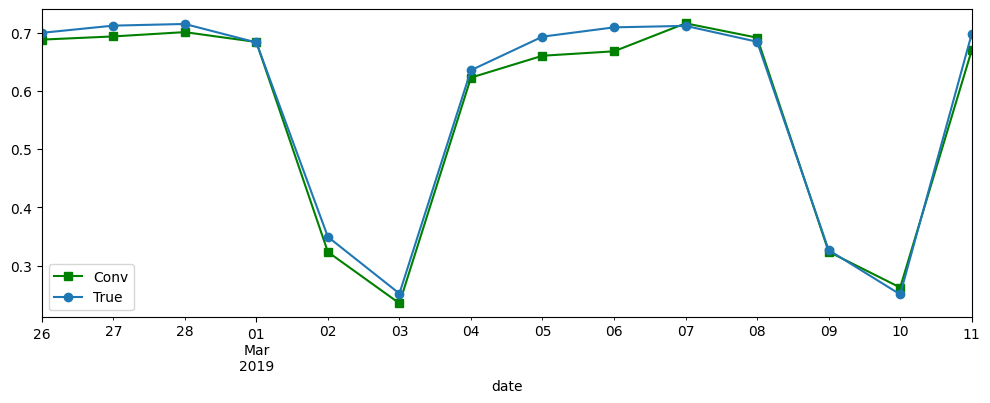

In [51]:
y_true = mulvar_valid['rail'][seq_length:seq_length + 14]
y_pred_14_conv  = pd.Series(y_pred_14_conv, y_true.index)

fig, ax = plt.subplots(figsize=(12, 4))

y_pred_14_conv.plot(ax=ax, c='g', marker='s', label='Conv')
y_true.plot(ax=ax, marker='o', label='True')
plt.legend()

In [60]:
reload(tf_model)
from tf_model import Sequential, SimpleRNN, Dense, Input, EarlyStopping, Adam, Conv1D

test = Sequential([
    Input([seq_length, 5]),
    SimpleRNN(32, return_sequences=True),
    Conv1D(14, kernel_size=1)
])

test.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])
callbacks = [EarlyStopping(patience=20, restore_best_weights=True)]
test.fit(seq2seq_train_cus, epochs=100, validation_data=(seq2seq_valid_cus), callbacks=callbacks)

[56, 32]
Epoch 1/100


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

33it [00:11,  2.95it/s]


    - loss: 0.166 - meanabsolutepercentageerror: 0.304
    - val_loss: 0.080 - val_meanabsolutepercentageerror: 0.200
    - Learning Rate: 0.01
Epoch 2/100


...

    - loss: 0.051 - meanabsolutepercentageerror: 0.109
    - val_loss: 0.052 - val_meanabsolutepercentageerror: 0.133
    - Learning Rate: 0.01
Epoch 29/100


33it [00:02, 14.71it/s]


    - loss: 0.047 - meanabsolutepercentageerror: 0.102
    - val_loss: 0.046 - val_meanabsolutepercentageerror: 0.119
    - Learning Rate: 0.01
Epoch 30/100


33it [00:02, 15.00it/s]


    - loss: 0.046 - meanabsolutepercentageerror: 0.101
    - val_loss: 0.043 - val_meanabsolutepercentageerror: 0.116
    - Learning Rate: 0.01


## Task 4

да се имплмеентира класа TimeDistributed

In [17]:
reload(tf_model)
from tf_model import Sequential, SimpleRNN, Dense, Input, EarlyStopping, Adam, Conv1D, TimeDistributed

test = Sequential([
    Input([seq_length, 5]),
    SimpleRNN(32, return_sequences=True),
    TimeDistributed(Dense(14))
])

test.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])
callbacks = [EarlyStopping(patience=20, restore_best_weights=True)]
test.fit(seq2seq_train_cus, epochs=100, validation_data=(seq2seq_valid_cus), callbacks=callbacks)

Epoch 1/100


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

33it [00:08,  3.79it/s]


    - loss: 0.181 - meanabsolutepercentageerror: 0.334
    - val_loss: 0.068 - val_meanabsolutepercentageerror: 0.159
    - Learning Rate: 0.01
Epoch 2/100


...

    - loss: 0.046 - meanabsolutepercentageerror: 0.101
    - val_loss: 0.046 - val_meanabsolutepercentageerror: 0.123
    - Learning Rate: 0.01
Epoch 24/100


33it [00:02, 12.39it/s]


    - loss: 0.046 - meanabsolutepercentageerror: 0.099
    - val_loss: 0.046 - val_meanabsolutepercentageerror: 0.117
    - Learning Rate: 0.01
Epoch 25/100


33it [00:02, 12.83it/s]


    - loss: 0.049 - meanabsolutepercentageerror: 0.106
    - val_loss: 0.045 - val_meanabsolutepercentageerror: 0.124
    - Learning Rate: 0.01
